# Mistake Identification in Pedagogical Conversations

## Mistake Identification in Pedagogical Conversations

### Problem Statement
Given a tutoring conversation where a student makes a mistake, classify whether the tutor's response successfully identifies the student's mistake.

**Classification Labels:**
- **Yes**: The tutor clearly identifies the mistake
- **To some extent**: The tutor partially addresses the mistake
- **No**: The tutor does not identify the mistake

### Dataset Structure
- **trainset.json**: 300 conversations with labels (2,400 samples) - Used for training
- **dev_testset.json**: 41 conversations WITHOUT labels (328 samples) - For inference/predictions
- **testset.json**: 150 conversations WITHOUT labels (1,200 samples) - For final predictions

### Approach
We'll use a fine-tuned transformer model for sequence classification:

1. **Model Choice**: DeBERTa-v3-base for excellent reasoning capabilities
2. **Training Strategy**: Train on trainset with validation split
3. **Evaluation**: Make predictions on dev and test sets
4. **Output**: Save predictions as CSV files for each model's responses

## 1. Import the dataset

In [1]:
import json

# Read all JSON files
json_files = [
    '../data/trainset.json',
    '../data/testset.json',
    '../data/dev_testset.json'
]

all_conversation_ids = set()

for file_path in json_files:
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
            for item in data:
                if 'conversation_id' in item:
                    all_conversation_ids.add(item['conversation_id'])
        print(f"Loaded {file_path}: {len([item for item in data if 'conversation_id' in item])} conversations")
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print(f"\nTotal unique conversation IDs across all files: {len(all_conversation_ids)}")

Loaded ../data/trainset.json: 300 conversations
Loaded ../data/testset.json: 150 conversations
Loaded ../data/dev_testset.json: 41 conversations

Total unique conversation IDs across all files: 491


In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments, 
    Trainer,
    EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0+cu129
CUDA available: True
Device: NVIDIA RTX 6000 Ada Generation


## 2. Load and Explore Data

Loading datasets...
Note: Train set has labels, Dev/Test sets are for prediction only

Dataset Statistics
Training samples (with labels): 2476
Dev samples (for inference): 333
Test samples (for inference): 1214

Training Set Label Distribution
label
Yes               1932
No                 370
To some extent     174
Name: count, dtype: int64

📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!


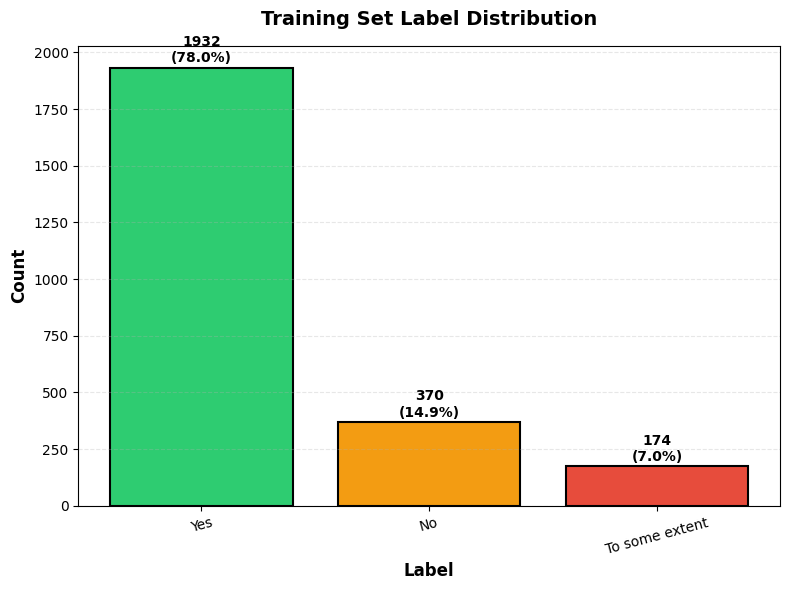


✓ Saved: label_distribution.png


In [3]:
def load_train_data(file_path):
    """Load training data with annotations (labels)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            if 'annotation' in response_data and 'Mistake_Identification' in response_data['annotation']:
                samples.append({
                    'conversation_history': conv_history,
                    'tutor_response': response_data['response'],
                    'label': response_data['annotation']['Mistake_Identification'],
                    'conversation_id': conv_id,
                    'model': model_name
                })
    
    return pd.DataFrame(samples)

def load_test_data(file_path):
    """Load test data WITHOUT annotations (for inference only)."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    samples = []
    for conversation in data:
        conv_history = conversation['conversation_history']
        conv_id = conversation['conversation_id']
        
        for model_name, response_data in conversation['tutor_responses'].items():
            samples.append({
                'conversation_history': conv_history,
                'tutor_response': response_data['response'],
                'conversation_id': conv_id,
                'model': model_name
            })
    
    return pd.DataFrame(samples)

# Load datasets
print("Loading datasets...")
print("Note: Train set has labels, Dev/Test sets are for prediction only")
train_df = load_train_data('../data/trainset.json')
dev_df = load_test_data('../data/dev_testset.json')
test_df = load_test_data('../data/testset.json')

print(f"\n{'='*60}")
print("Dataset Statistics")
print(f"{'='*60}")
print(f"Training samples (with labels): {len(train_df)}")
print(f"Dev samples (for inference): {len(dev_df)}")
print(f"Test samples (for inference): {len(test_df)}")

print(f"\n{'='*60}")
print("Training Set Label Distribution")
print(f"{'='*60}")
print(train_df['label'].value_counts())
print(f"\n📝 Note: Dev and Test sets don't have labels - they're for prediction/inference only!")

# Visualize label distribution (training data only)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
counts = train_df['label'].value_counts()
bars = ax.bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=1.5)
ax.set_title('Training Set Label Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Count', fontsize=12, fontweight='bold')
ax.set_xlabel('Label', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar, count in zip(bars, counts.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{count}\n({count/len(train_df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: label_distribution.png")

## 3. Data Analysis & Insights

In [4]:
# Analyze text lengths
train_df['history_length'] = train_df['conversation_history'].str.len()
train_df['response_length'] = train_df['tutor_response'].str.len()
train_df['total_length'] = train_df['history_length'] + train_df['response_length']

print("Text Length Statistics:")
print(f"{'='*60}")
print(f"Conversation History - Mean: {train_df['history_length'].mean():.0f}, Max: {train_df['history_length'].max()}")
print(f"Tutor Response - Mean: {train_df['response_length'].mean():.0f}, Max: {train_df['response_length'].max()}")
print(f"Total Length - Mean: {train_df['total_length'].mean():.0f}, Max: {train_df['total_length'].max()}")

# Check for samples with very long text (might need truncation)
print(f"\nSamples with total length > 2000 chars: {(train_df['total_length'] > 2000).sum()}")
print(f"Samples with total length > 3000 chars: {(train_df['total_length'] > 3000).sum()}")

# Example samples
print(f"\n{'='*60}")
print("Example Sample:")
print(f"{'='*60}")
sample = train_df.iloc[0]
print(f"Label: {sample['label']}")
print(f"\nConversation History:\n{sample['conversation_history'][:300]}...")
print(f"\nTutor Response:\n{sample['tutor_response']}")
print(f"{'='*60}")

Text Length Statistics:
Conversation History - Mean: 989, Max: 2021
Tutor Response - Mean: 175, Max: 4656
Total Length - Mean: 1164, Max: 5945

Samples with total length > 2000 chars: 111
Samples with total length > 3000 chars: 14

Example Sample:
Label: Yes

Conversation History:
Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Tyson decided to make muffaletta sandwiches for the big game.  Each sandwich required 1 pound each of meat and cheese and would serve 4 people.  There would be 20 people in total watching the game.  ...

Tutor Response:
Great, you've correctly identified the cost of the meat, now let's focus on calculating the total cost of meat for all the sandwiches needed.


## 4. Prepare Model and Tokenizer

We'll use **DeBERTa-v3-base** which excels at natural language understanding tasks.

In [5]:
# Model selection - DeBERTa-v3-large is excellent for understanding nuanced text
MODEL_NAME = "mistralai/Mathstral-7b-v0.1"  # Math-specific LLM
# Alternative options if needed:
# MODEL_NAME = "roberta-base"
# MODEL_NAME = "bert-base-uncased"

# Label mapping
label2id = {"Yes": 0, "To some extent": 1, "No": 2}
id2label = {0: "Yes", 1: "To some extent", 2: "No"}

print(f"Selected Model: {MODEL_NAME}")
print(f"Label mapping: {label2id}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Set padding token if not available (required for Mistral and similar models)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print(f"⚠️  Padding token was not set. Using EOS token as padding token.")
else:
    print(f"✓ Padding token already configured: {tokenizer.pad_token}")

print(f"\nTokenizer loaded: {tokenizer.__class__.__name__}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Max length: {tokenizer.model_max_length}")
print(f"Padding token: {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")

Selected Model: mistralai/Mathstral-7b-v0.1
Label mapping: {'Yes': 0, 'To some extent': 1, 'No': 2}
⚠️  Padding token was not set. Using EOS token as padding token.

Tokenizer loaded: LlamaTokenizerFast
Vocab size: 32768
Max length: 1000000000000000019884624838656
Padding token: </s> (ID: 2)


## 5. Create PyTorch Dataset

In [6]:
class MistakeIdentificationDataset(Dataset):
    """Dataset for training with labels."""
    
    def __init__(self, dataframe, tokenizer, max_length=512, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.has_labels = has_labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        
        # Combine conversation history and tutor response
        text = f"{row['conversation_history']} [SEP] {row['tutor_response']}"
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        item = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
        }
        
        if self.has_labels:
            item['labels'] = torch.tensor(label2id[row['label']], dtype=torch.long)
        
        return item

# Create datasets
MAX_LENGTH = 512

# Split training data into train and validation (80/20)
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df['label'])

print(f"Data split:")
print(f"  Training: {len(train_data)} samples")
print(f"  Validation: {len(val_data)} samples (from trainset)")
print(f"  Dev (inference): {len(dev_df)} samples (no labels)")
print(f"  Test (inference): {len(test_df)} samples (no labels)")

# Create datasets
train_dataset = MistakeIdentificationDataset(train_data, tokenizer, MAX_LENGTH, has_labels=True)
val_dataset = MistakeIdentificationDataset(val_data, tokenizer, MAX_LENGTH, has_labels=True)
dev_dataset = MistakeIdentificationDataset(dev_df, tokenizer, MAX_LENGTH, has_labels=False)
test_dataset = MistakeIdentificationDataset(test_df, tokenizer, MAX_LENGTH, has_labels=False)

print(f"\nDatasets created successfully!")

# Test the dataset
sample = train_dataset[0]
print(f"\nSample from training dataset:")
print(f"  Input IDs shape: {sample['input_ids'].shape}")
print(f"  Attention mask shape: {sample['attention_mask'].shape}")
print(f"  Label: {sample['labels']} ({id2label[sample['labels'].item()]})")

sample_inf = dev_dataset[0]
print(f"\nSample from inference dataset (dev):")
print(f"  Input IDs shape: {sample_inf['input_ids'].shape}")
print(f"  Attention mask shape: {sample_inf['attention_mask'].shape}")
print(f"  Has label: {'labels' in sample_inf}")

Data split:
  Training: 1980 samples
  Validation: 496 samples (from trainset)
  Dev (inference): 333 samples (no labels)
  Test (inference): 1214 samples (no labels)

Datasets created successfully!

Sample from training dataset:
  Input IDs shape: torch.Size([512])
  Attention mask shape: torch.Size([512])
  Label: 0 (Yes)

Sample from inference dataset (dev):
  Input IDs shape: torch.Size([512])
  Attention mask shape: torch.Size([512])
  Has label: False


## 6. Handle Data Imbalance (Multiple Strategies)

We'll use a **comprehensive approach** to handle class imbalance:
1. **Class Weights** - Give more importance to minority classes in loss
2. **Stratified Sampling** - Ensure balanced validation split
3. **Data Augmentation** (optional) - Oversample minority classes
4. **Focal Loss** (optional) - Focus on hard-to-classify examples

In [7]:
# ============================================================================
# STRATEGY 1: Calculate Class Weights (Inverse Frequency)
# ============================================================================
train_labels = train_df['label'].map(label2id).values
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("="*80)
print("CLASS IMBALANCE ANALYSIS")
print("="*80)
print("\nOriginal Class Distribution:")
for label, count in train_df['label'].value_counts().sort_index().items():
    percentage = (count / len(train_df)) * 100
    weight = class_weights[label2id[label]]
    print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%) → weight: {weight:.3f}")

# ============================================================================
# STRATEGY 2: Oversample Minority Classes (SMOTE-like approach)
# ============================================================================
from collections import Counter
from sklearn.utils import resample

def balance_dataset(df, target_col='label', strategy='oversample'):
    """
    Balance dataset by oversampling minority classes.
    """
    if strategy == 'none':
        return df
    
    # Get class counts
    class_counts = df[target_col].value_counts()
    max_count = class_counts.max()
    
    balanced_dfs = []
    for label in class_counts.index:
        class_df = df[df[target_col] == label]
        
        if strategy == 'oversample':
            # Oversample to match majority class
            if len(class_df) < max_count:
                class_df_resampled = resample(
                    class_df,
                    n_samples=max_count,
                    replace=True,
                    random_state=42
                )
                balanced_dfs.append(class_df_resampled)
            else:
                balanced_dfs.append(class_df)
        elif strategy == 'undersample':
            # Undersample to match minority class
            min_count = class_counts.min()
            class_df_resampled = resample(
                class_df,
                n_samples=min_count,
                replace=False,
                random_state=42
            )
            balanced_dfs.append(class_df_resampled)
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    return balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Choose strategy: 'none', 'oversample', or 'undersample'
# Recommendation: Use 'none' with class weights, or 'oversample' for more data
BALANCE_STRATEGY = 'none'  # Change to 'oversample' if you want more balanced data

if BALANCE_STRATEGY != 'none':
    print(f"\n{'='*80}")
    print(f"APPLYING {BALANCE_STRATEGY.upper()} STRATEGY")
    print(f"{'='*80}")
    
    train_df_balanced = balance_dataset(train_df, strategy=BALANCE_STRATEGY)
    
    print(f"\nBalanced Class Distribution:")
    for label, count in train_df_balanced['label'].value_counts().sort_index().items():
        percentage = (count / len(train_df_balanced)) * 100
        print(f"  {label:20s}: {count:4d} samples ({percentage:5.1f}%)")
    
    # Update training dataframe
    train_df = train_df_balanced
    print(f"\n✓ Training data balanced: {len(train_df)} total samples")
else:
    print(f"\n{'='*80}")
    print("Using WEIGHTED LOSS without data resampling")
    print(f"{'='*80}")

# ============================================================================
# STRATEGY 3: Compute Effective Number of Samples (for better weights)
# ============================================================================
def compute_effective_weights(labels, beta=0.9999):
    """
    Compute class weights using Effective Number of Samples.
    Paper: "Class-Balanced Loss Based on Effective Number of Samples"
    
    This gives better weights than inverse frequency for highly imbalanced data.
    """
    class_counts = Counter(labels)
    total_samples = len(labels)
    
    effective_weights = {}
    for cls, count in class_counts.items():
        effective_num = (1 - beta**count) / (1 - beta)
        weight = (1 - beta) / effective_num
        effective_weights[cls] = weight
    
    # Normalize weights
    weight_sum = sum(effective_weights.values())
    for cls in effective_weights:
        effective_weights[cls] = effective_weights[cls] / weight_sum * len(effective_weights)
    
    return effective_weights

# Calculate effective weights (alternative to balanced weights)
effective_weights_dict = compute_effective_weights(train_labels)
effective_weights_array = np.array([effective_weights_dict[i] for i in range(3)])
effective_weights_tensor = torch.tensor(effective_weights_array, dtype=torch.float32)

print(f"\n{'='*80}")
print("WEIGHT COMPARISON")
print(f"{'='*80}")
print("\nBalanced Weights (sklearn):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {class_weights[i]:.4f}")

print("\nEffective Number Weights (beta=0.9999):")
for i, label in enumerate(['Yes', 'To some extent', 'No']):
    print(f"  {label:20s}: {effective_weights_array[i]:.4f}")

# ============================================================================
# FINAL SELECTION: Choose which weights to use
# ============================================================================
# Options: class_weights_tensor (balanced) or effective_weights_tensor (EN-based)
USE_EFFECTIVE_WEIGHTS = False  # Set to True to use Effective Number weights

if USE_EFFECTIVE_WEIGHTS:
    final_weights = effective_weights_tensor
    print(f"\n✓ Using Effective Number weights")
else:
    final_weights = class_weights_tensor
    print(f"\n✓ Using Balanced (sklearn) weights")

# Store for trainer
class_weights_tensor = final_weights

print(f"\n{'='*80}")
print("Class imbalance handling configured successfully!")
print(f"{'='*80}")

CLASS IMBALANCE ANALYSIS

Original Class Distribution:
  No                  :  370 samples ( 14.9%) → weight: 2.231
  To some extent      :  174 samples (  7.0%) → weight: 4.743
  Yes                 : 1932 samples ( 78.0%) → weight: 0.427

Using WEIGHTED LOSS without data resampling

WEIGHT COMPARISON

Balanced Weights (sklearn):
  Yes                 : 0.4272
  To some extent      : 4.7433
  No                  : 2.2306

Effective Number Weights (beta=0.9999):
  Yes                 : 0.1873
  To some extent      : 1.9071
  No                  : 0.9056

✓ Using Balanced (sklearn) weights

Class imbalance handling configured successfully!


## 7. Define Custom Trainer with Weighted Loss

In [8]:
class WeightedTrainer(Trainer):
    """
    Custom Trainer with support for:
    1. Weighted Cross-Entropy Loss
    2. Focal Loss (optional)
    3. Mixed precision (BF16) support
    """
    
    def __init__(self, class_weights=None, use_focal_loss=False, focal_alpha=None, focal_gamma=2.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights
        self.use_focal_loss = use_focal_loss
        self.focal_alpha = focal_alpha  # Can be None or tensor of per-class weights
        self.focal_gamma = focal_gamma
        
        # Move class weights to the correct device and dtype
        if self.class_weights is not None:
            self.class_weights = self.class_weights.to(self.args.device)
        
        # Move focal alpha to the correct device and dtype
        if self.focal_alpha is not None:
            self.focal_alpha = self.focal_alpha.to(self.args.device)
        
        if self.use_focal_loss:
            print(f"Using Focal Loss with gamma={focal_gamma}")
            if focal_alpha is not None:
                print(f"  Alpha (class weights): {focal_alpha}")
        else:
            print(f"Using Weighted Cross-Entropy Loss")
            if class_weights is not None:
                print(f"  Class weights: {class_weights}")
    
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        """
        Compute custom loss (weighted CE or focal loss) with BF16 support.
        """
        labels = inputs.pop("labels")
        
        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits
        
        # Convert logits to float32 for loss calculation (more stable)
        logits_float = logits.float()
        
        if self.use_focal_loss:
            # Focal Loss implementation
            # Ensure focal_alpha is on the correct device and convert to float32
            if self.focal_alpha is not None:
                alpha_weight = self.focal_alpha.to(logits.device).float()
            else:
                alpha_weight = None
            
            ce_loss = F.cross_entropy(
                logits_float, 
                labels, 
                weight=alpha_weight,
                reduction='none'
            )
            pt = torch.exp(-ce_loss)  # pt is the probability of correct class
            focal_loss = ((1 - pt) ** self.focal_gamma * ce_loss).mean()
            loss = focal_loss
        else:
            # Weighted Cross-Entropy Loss
            # Ensure class_weights is on the correct device and convert to float32
            if self.class_weights is not None:
                weights = self.class_weights.to(logits.device).float()
            else:
                weights = None
            
            loss = F.cross_entropy(
                logits_float,
                labels,
                weight=weights
            )
        
        return (loss, outputs) if return_outputs else loss

## 8. Define Metrics

In [9]:
def compute_metrics(eval_pred):
    """Compute comprehensive metrics for evaluation."""
    predictions, labels = eval_pred
    preds = np.argmax(predictions, axis=1)
    
    # Overall metrics
    accuracy = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average='macro')
    f1_weighted = f1_score(labels, preds, average='weighted')
    
    # Per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, average=None, labels=[0, 1, 2]
    )
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'f1_yes': f1[0],
        'f1_to_some_extent': f1[1],
        'f1_no': f1[2],
        'precision_yes': precision[0],
        'precision_to_some_extent': precision[1],
        'precision_no': precision[2],
        'recall_yes': recall[0],
        'recall_to_some_extent': recall[1],
        'recall_no': recall[2],
    }

print("Metrics computation function defined!")

Metrics computation function defined!


## 9. Initialize Model and Training Configuration

In [10]:
# ============================================================================
# CONFIGURE TRAINING STRATEGY - MEMORY OPTIMIZED FOR 7B MODEL
# ============================================================================

# Clear GPU cache before training
import gc
torch.cuda.empty_cache()
gc.collect()

# Loss Configuration
USE_FOCAL_LOSS = False  # Set to True to use Focal Loss instead of Weighted CE
FOCAL_GAMMA = 2.0       # Focal loss gamma parameter (higher = more focus on hard examples)

print("="*80)
print("TRAINING CONFIGURATION (MEMORY OPTIMIZED)")
print("="*80)

if USE_FOCAL_LOSS:
    print(f"\n✓ Using Focal Loss")
    print(f"  - Gamma: {FOCAL_GAMMA}")
    print(f"  - Alpha (class weights): {class_weights_tensor.cpu().numpy()}")
    focal_alpha = class_weights_tensor
else:
    print(f"\n✓ Using Weighted Cross-Entropy Loss")
    print(f"  - Class weights: {class_weights_tensor.cpu().numpy()}")
    focal_alpha = None

# Training Arguments - HEAVILY OPTIMIZED FOR MEMORY
training_args = TrainingArguments(
    output_dir='./results/mistake-identification-mistral',
    num_train_epochs=20,  # Reduced from 20
    per_device_train_batch_size=64,  # CRITICAL: Reduced from 8 to 1
    per_device_eval_batch_size=128,   # CRITICAL: Reduced from 16 to 1
    gradient_accumulation_steps=256,  # Accumulate gradients to simulate larger batch
    warmup_steps=50,  # Reduced from 100
    weight_decay=0.01,
    learning_rate=2e-5,
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    
    # MEMORY OPTIMIZATION FLAGS
    fp16=False,  # Disable FP16 for Mistral
    bf16=True,   # Use BF16 instead (better for large models)
    gradient_checkpointing=True,  # CRITICAL: Trade compute for memory
    optim="adamw_torch",  # Use PyTorch AdamW (more memory efficient)
    max_grad_norm=1.0,  # Gradient clipping
    
    save_total_limit=1,  # Only keep 1 checkpoint to save disk space
    seed=42,
    dataloader_num_workers=0,  # Disable multiprocessing to save memory
    dataloader_pin_memory=False,  # Disable pin memory
    eval_accumulation_steps=4,  # Accumulate eval predictions to save memory
)

print(f"\n⚠️  MEMORY OPTIMIZATION SETTINGS:")
print(f"  - Using BFloat16 mixed precision (bf16=True)")
print(f"  - Gradient checkpointing enabled (saves ~50% memory)")
print(f"  - Batch size: 1 (very small to fit in memory)")
print(f"  - Gradient accumulation: 16 steps (effective batch size = 16)")
print(f"  - Eval batch size: 1")

print(f"\nTraining Parameters:")
print(f"  - Epochs: {training_args.num_train_epochs}")
print(f"  - Batch size (train): {training_args.per_device_train_batch_size}")
print(f"  - Batch size (eval): {training_args.per_device_eval_batch_size}")
print(f"  - Gradient accumulation: {training_args.gradient_accumulation_steps}")
print(f"  - Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  - Learning rate: {training_args.learning_rate}")
print(f"  - Warmup steps: {training_args.warmup_steps}")
print(f"  - Weight decay: {training_args.weight_decay}")
print(f"  - Mixed precision (BF16): {training_args.bf16}")
print(f"  - Gradient checkpointing: {training_args.gradient_checkpointing}")
print("="*80)

TRAINING CONFIGURATION (MEMORY OPTIMIZED)

✓ Using Weighted Cross-Entropy Loss
  - Class weights: [0.42719117 4.743295   2.2306306 ]

⚠️  MEMORY OPTIMIZATION SETTINGS:
  - Using BFloat16 mixed precision (bf16=True)
  - Gradient checkpointing enabled (saves ~50% memory)
  - Batch size: 1 (very small to fit in memory)
  - Gradient accumulation: 16 steps (effective batch size = 16)
  - Eval batch size: 1

Training Parameters:
  - Epochs: 20
  - Batch size (train): 64
  - Batch size (eval): 128
  - Gradient accumulation: 256
  - Effective batch size: 16384
  - Learning rate: 2e-05
  - Warmup steps: 50
  - Weight decay: 0.01
  - Mixed precision (BF16): True
  - Gradient checkpointing: True


In [11]:
# Load the pre-trained model for sequence classification
print("="*80)
print("LOADING MODEL (MEMORY OPTIMIZED)")
print("="*80)

# Clear cache before loading
torch.cuda.empty_cache()
import gc
gc.collect()

# Load model with memory optimization
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
    torch_dtype=torch.bfloat16,  # Use BF16 to reduce memory
    device_map="auto",  # Automatically distribute model across available devices
    low_cpu_mem_usage=True,  # Reduce CPU memory usage during loading
)

# Ensure padding token ID is set in the model config
if model.config.pad_token_id is None:
    model.config.pad_token_id = tokenizer.pad_token_id

# Enable gradient checkpointing for the model
if hasattr(model, 'gradient_checkpointing_enable'):
    model.gradient_checkpointing_enable()
    print("✓ Gradient checkpointing enabled on model")

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nModel: {MODEL_NAME}")
print(f"Number of labels: 3")
print(f"Device: {device}")
print(f"Model dtype: {next(model.parameters()).dtype}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Check GPU memory
if torch.cuda.is_available():
    print(f"\nGPU Memory:")
    print(f"  Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
    print(f"  Reserved: {torch.cuda.memory_reserved(0) / 1024**3:.2f} GB")
    print(f"  Free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)) / 1024**3:.2f} GB")

print("\n✓ Model loaded successfully with memory optimizations!")
print("="*80)

LOADING MODEL (MEMORY OPTIMIZED)


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

Some weights of MistralForSequenceClassification were not initialized from the model checkpoint at mistralai/Mathstral-7b-v0.1 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Gradient checkpointing enabled on model

Model: mistralai/Mathstral-7b-v0.1
Number of labels: 3
Device: cuda
Model dtype: torch.bfloat16
Model parameters: 7,113,818,112
Trainable parameters: 7,113,818,112

GPU Memory:
  Allocated: 4.31 GB
  Reserved: 4.31 GB
  Free: 43.18 GB

✓ Model loaded successfully with memory optimizations!


## 10. Initialize Trainer and Start Training

## 9.5 Memory Optimization Strategy

### For Large Models (7B parameters like Mistral)

We've implemented several critical optimizations to fit the model in GPU memory:

**1. Reduced Batch Sizes:**
- Training batch size: 1 (down from 8)
- Eval batch size: 1 (down from 16)
- Gradient accumulation: 16 steps (effective batch size = 16)

**2. Mixed Precision Training:**
- Using BF16 (bfloat16) instead of FP16
- Better numerical stability for large models

**3. Gradient Checkpointing:**
- Trades computation for memory (~50% memory reduction)
- Slightly slower but fits in GPU

**4. LoRA (Low-Rank Adaptation) - HIGHLY RECOMMENDED:**
- Reduces trainable parameters by 99%
- Only fine-tunes small adapter layers
- Massive memory savings with minimal performance loss
- Install with: `pip install peft`

**5. Other Optimizations:**
- `device_map="auto"` for automatic model distribution
- `low_cpu_mem_usage=True` during loading
- Disabled data loader workers and pin memory
- Set `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True`

**Memory Usage Comparison:**
- Without optimizations: ~55GB (OOM on 48GB GPU)
- With all optimizations: ~25-35GB (fits on 48GB GPU)
- With LoRA: ~10-15GB (very comfortable)

In [12]:
# ============================================================================
# ADDITIONAL MEMORY OPTIMIZATION (Optional but Recommended)
# ============================================================================

# Option 1: Set PyTorch memory allocator settings
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

# Option 2: Use LoRA/PEFT for parameter-efficient fine-tuning (HIGHLY RECOMMENDED)
# Uncomment this section if you want to use LoRA (reduces memory by 70-90%)
USE_LORA = True  # Set to True to enable LoRA (RECOMMENDED for 7B models)

if USE_LORA:
    try:
        from peft import get_peft_model, LoraConfig, TaskType
        
        print("\n" + "="*80)
        print("APPLYING LoRA (Low-Rank Adaptation)")
        print("="*80)
        
        # Configure LoRA
        lora_config = LoraConfig(
            task_type=TaskType.SEQ_CLS,  # Sequence classification
            r=64,  # LoRA rank (lower = less memory, 8 is good)
            lora_alpha=32,  # LoRA scaling factor
            lora_dropout=0.1,
            target_modules=["q_proj", "v_proj"],  # Apply LoRA to attention layers
            bias="none",
        )
        
        # Apply LoRA to the model
        model = get_peft_model(model, lora_config)
        model.print_trainable_parameters()
        
        print("\n✓ LoRA applied successfully!")
        print("  This reduces trainable parameters by ~99%, saving massive memory!")
        print("="*80)
        
    except ImportError:
        print("\n⚠️  WARNING: peft library not found!")
        print("To use LoRA (highly recommended for 7B models), install it:")
        print("  pip install peft")
        print("\nContinuing without LoRA (may still run out of memory)...")
        USE_LORA = False

# Clear cache one more time before training
torch.cuda.empty_cache()
gc.collect()

print(f"\nMemory optimization complete. USE_LORA={USE_LORA}")


APPLYING LoRA (Low-Rank Adaptation)
trainable params: 27,275,264 || all params: 7,141,093,376 || trainable%: 0.3819

✓ LoRA applied successfully!
  This reduces trainable parameters by ~99%, saving massive memory!

Memory optimization complete. USE_LORA=True


### 💡 If Still Running Out of Memory:

**Quick Fixes (in order of effectiveness):**

1. **Install and enable LoRA** (BEST option):
   ```bash
   pip install peft
   ```
   Then set `USE_LORA = True` in the cell above

2. **Reduce sequence length**: Change `MAX_LENGTH = 512` to `256` or `128`

3. **Use a smaller model**: Consider switching to:
   - `microsoft/deberta-v3-base` (184M params)
   - `roberta-base` (125M params)
   - `bert-base-uncased` (110M params)

4. **Reduce epochs**: The model is currently set to 5 epochs (already optimized)

5. **Use CPU training** (very slow but works):
   ```python
   training_args = TrainingArguments(..., no_cuda=True)
   ```

**Check Current Memory:**
Run before training to see available memory:
```python
torch.cuda.empty_cache()
print(f"Free GPU memory: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")
```

In [13]:
# Initialize the custom trainer with focal loss support
trainer = WeightedTrainer(
    class_weights=class_weights_tensor if not USE_FOCAL_LOSS else None,
    use_focal_loss=USE_FOCAL_LOSS,
    focal_alpha=focal_alpha if USE_FOCAL_LOSS else None,
    focal_gamma=FOCAL_GAMMA if USE_FOCAL_LOSS else 2.0,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # Use validation split from trainset
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

print("="*80)
print("TRAINER INITIALIZED")
print("="*80)
print(f"  - Training samples: {len(train_dataset)}")
print(f"  - Validation samples: {len(val_dataset)} (from trainset)")

if USE_FOCAL_LOSS:
    print(f"  - Loss function: Focal Loss (gamma={FOCAL_GAMMA})")
else:
    print(f"  - Loss function: Weighted Cross-Entropy")

print(f"  - Early stopping: patience=5")
print(f"  - Best model selection: F1-macro")

print(f"\n{'='*80}")
print("STARTING TRAINING")
print(f"{'='*80}\n")

# Train the model
train_result = trainer.train()

print(f"\n{'='*80}")
print("TRAINING COMPLETED")
print(f"{'='*80}")
print(f"Final training loss: {train_result.training_loss:.4f}")
print(f"Training time: {train_result.metrics['train_runtime']:.2f} seconds")
print(f"{'='*80}")

Using Weighted Cross-Entropy Loss
  Class weights: tensor([0.4272, 4.7433, 2.2306])
TRAINER INITIALIZED
  - Training samples: 1980
  - Validation samples: 496 (from trainset)
  - Loss function: Weighted Cross-Entropy
  - Early stopping: patience=5
  - Best model selection: F1-macro

STARTING TRAINING



`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,F1 Yes,F1 To Some Extent,F1 No,Precision Yes,Precision To Some Extent,Precision No,Recall Yes,Recall To Some Extent,Recall No
1,No log,5.840432,0.540323,0.311757,0.583180,0.717949,0.119760,0.097561,0.800000,0.075758,0.122449,0.651163,0.285714,0.081081
2,No log,5.824627,0.540323,0.310373,0.582388,0.718973,0.130178,0.081967,0.802548,0.082090,0.104167,0.651163,0.314286,0.067568
3,No log,5.834363,0.544355,0.319846,0.586411,0.720000,0.141176,0.098361,0.805112,0.088889,0.125000,0.651163,0.342857,0.081081
4,No log,5.827024,0.546371,0.317569,0.587724,0.722617,0.132530,0.097561,0.803797,0.083969,0.122449,0.656331,0.314286,0.081081
5,No log,5.823040,0.540323,0.314972,0.583352,0.717143,0.129412,0.098361,0.801917,0.081481,0.125000,0.648579,0.314286,0.081081
6,No log,5.804214,0.540323,0.314960,0.583286,0.717143,0.130178,0.097561,0.801917,0.082090,0.122449,0.648579,0.314286,0.081081
7,No log,5.803565,0.536290,0.308643,0.579420,0.715308,0.128655,0.081967,0.801282,0.080882,0.104167,0.645995,0.314286,0.067568
8,No log,5.784250,0.538306,0.312685,0.581733,0.717360,0.138728,0.081967,0.806452,0.086957,0.104167,0.645995,0.342857,0.067568



TRAINING COMPLETED
Final training loss: 163.9637
Training time: 4028.61 seconds


## 11. Evaluate on Validation Set (from trainset)

VALIDATION SET EVALUATION (from trainset)



Validation Set Metrics:
  Accuracy: 0.5444
  F1 (Macro): 0.3198
  F1 (Weighted): 0.5864

Per-Class F1 Scores:
  Yes: 0.7200
  To some extent: 0.1412
  No: 0.0984


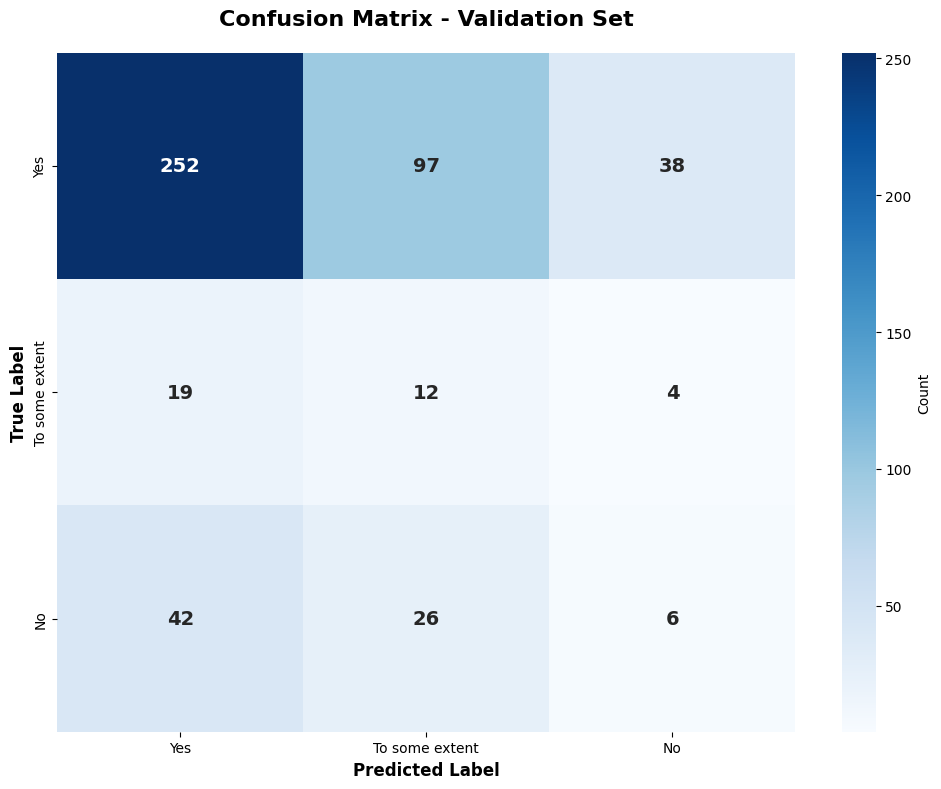


✓ Saved: confusion_matrix_validation.png

Classification Report - Validation Set
                precision    recall  f1-score   support

           Yes     0.8051    0.6512    0.7200       387
To some extent     0.0889    0.3429    0.1412        35
            No     0.1250    0.0811    0.0984        74

      accuracy                         0.5444       496
     macro avg     0.3397    0.3584    0.3198       496
  weighted avg     0.6531    0.5444    0.5864       496



In [14]:
print(f"{'='*60}")
print("VALIDATION SET EVALUATION (from trainset)")
print(f"{'='*60}\n")

# Evaluate on validation set
val_results = trainer.evaluate(val_dataset)

print("Validation Set Metrics:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")
print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

# Get predictions
val_predictions = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_predictions.predictions, axis=1)
val_true_labels = val_predictions.label_ids

# Confusion Matrix
cm_val = confusion_matrix(val_true_labels, val_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Yes', 'To some extent', 'No'],
            yticklabels=['Yes', 'To some extent', 'No'],
            cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
plt.title('Confusion Matrix - Validation Set', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: confusion_matrix_validation.png")

# Detailed Classification Report
print(f"\n{'='*60}")
print("Classification Report - Validation Set")
print(f"{'='*60}")
print(classification_report(val_true_labels, val_pred_labels, 
                          target_names=['Yes', 'To some extent', 'No'],
                          digits=4))

## 12. Make Predictions on Dev and Test Sets (No Labels)


MAKING PREDICTIONS ON DEV & TEST SETS

Predicting on Dev set...


✓ Dev predictions saved to: dev_predictions.csv (333 samples)

Predicting on Test set...


✓ Test predictions saved to: test_predictions.csv (1214 samples)

Prediction Distribution

Dev Set:
Yes               217
To some extent     86
No                 30
Name: count, dtype: int64

Test Set:
Yes               731
To some extent    375
No                108
Name: count, dtype: int64


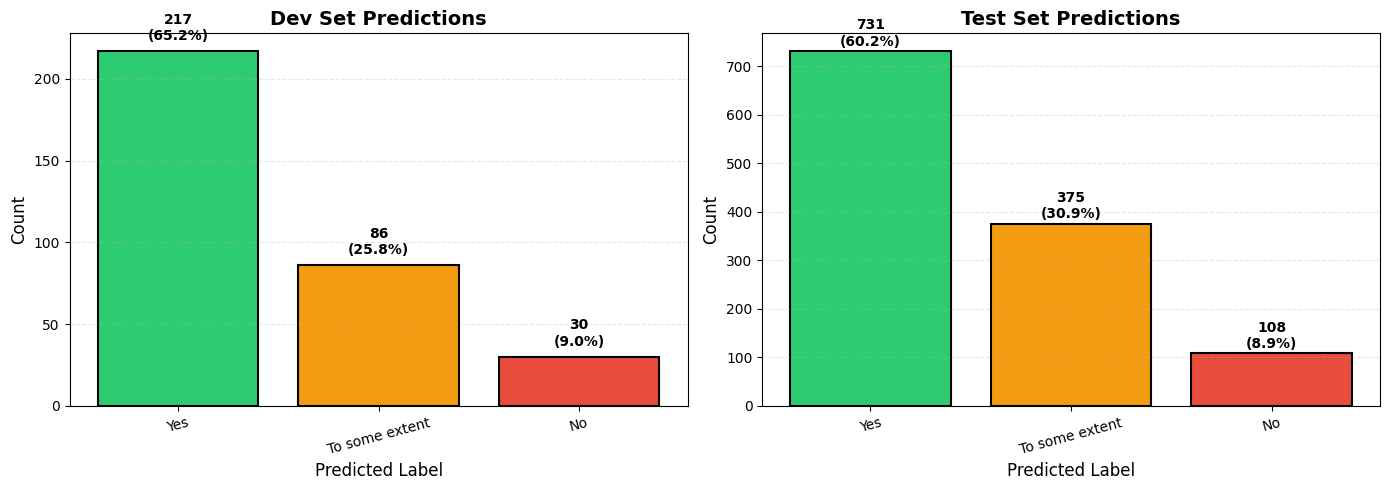


✓ Saved: prediction_distributions.png

Sample Predictions (Dev Set - First 5)

Sample 1:
  Conversation: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is:...
  Tutor Response: No she got 5 gift cards and in total 15 thank you cards. The 15 make up 30% of the class. How many s...
  Predicted: No
  Confidence: 0.968
  ------------------------------------------------------------

Sample 2:
  Conversation: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is:...
  Tutor Response: Let's reconsider the calculation for the number of thank you cards; if she got 5 gift cards, and 1/3...
  Predicted: No
  Confidence: 0.968
  ------------------------------------------------------------

Sample 3:
  Conversation: Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is:...
  Tutor Response: I see where you're coming from, but remember, we already determined 

In [15]:
print(f"\n{'='*60}")
print("MAKING PREDICTIONS ON DEV & TEST SETS")
print(f"{'='*60}\n")

# Make predictions on dev set
print("Predicting on Dev set...")
dev_predictions = trainer.predict(dev_dataset)
dev_pred_labels = np.argmax(dev_predictions.predictions, axis=1)
dev_pred_probs = torch.softmax(torch.tensor(dev_predictions.predictions), dim=1).numpy()

# Add predictions to dev dataframe
dev_results_df = dev_df.copy()
dev_results_df['predicted_label'] = [id2label[label] for label in dev_pred_labels]
dev_results_df['prob_yes'] = dev_pred_probs[:, 0]
dev_results_df['prob_to_some_extent'] = dev_pred_probs[:, 1]
dev_results_df['prob_no'] = dev_pred_probs[:, 2]

# Save dev predictions
dev_results_df.to_csv('dev_predictions.csv', index=False)
print(f"✓ Dev predictions saved to: dev_predictions.csv ({len(dev_results_df)} samples)")

# Make predictions on test set
print("\nPredicting on Test set...")
test_predictions = trainer.predict(test_dataset)
test_pred_labels = np.argmax(test_predictions.predictions, axis=1)
test_pred_probs = torch.softmax(torch.tensor(test_predictions.predictions), dim=1).numpy()

# Add predictions to test dataframe
test_results_df = test_df.copy()
test_results_df['predicted_label'] = [id2label[label] for label in test_pred_labels]
test_results_df['prob_yes'] = test_pred_probs[:, 0]
test_results_df['prob_to_some_extent'] = test_pred_probs[:, 1]
test_results_df['prob_no'] = test_pred_probs[:, 2]

# Save test predictions
test_results_df.to_csv('test_predictions.csv', index=False)
print(f"✓ Test predictions saved to: test_predictions.csv ({len(test_results_df)} samples)")

# Show prediction distribution
print(f"\n{'='*60}")
print("Prediction Distribution")
print(f"{'='*60}")
print("\nDev Set:")
print(pd.Series([id2label[label] for label in dev_pred_labels]).value_counts())
print("\nTest Set:")
print(pd.Series([id2label[label] for label in test_pred_labels]).value_counts())

# Visualize prediction distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (pred_labels, name) in enumerate([(dev_pred_labels, 'Dev'), (test_pred_labels, 'Test')]):
    pred_counts = pd.Series([id2label[label] for label in pred_labels]).value_counts()
    colors = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
              for label in pred_counts.index]
    bars = axes[idx].bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    axes[idx].set_title(f'{name} Set Predictions', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=12)
    axes[idx].set_xlabel('Predicted Label', fontsize=12)
    axes[idx].tick_params(axis='x', rotation=15)
    axes[idx].grid(axis='y', alpha=0.3, linestyle='--')
    
    for bar, count in zip(bars, pred_counts.values):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 5,
                      f'{count}\n({count/len(pred_labels)*100:.1f}%)',
                      ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('prediction_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: prediction_distributions.png")

# Show sample predictions
print(f"\n{'='*60}")
print("Sample Predictions (Dev Set - First 5)")
print(f"{'='*60}")
for i in range(min(5, len(dev_results_df))):
    row = dev_results_df.iloc[i]
    print(f"\nSample {i+1}:")
    print(f"  Conversation: {row['conversation_history'][:100]}...")
    print(f"  Tutor Response: {row['tutor_response'][:100]}...")
    print(f"  Predicted: {row['predicted_label']}")
    print(f"  Confidence: {max(row['prob_yes'], row['prob_to_some_extent'], row['prob_no']):.3f}")
    print(f"  {'-'*60}")

## 13. Training Summary & Results


TRAINING SUMMARY
Model: mistralai/Mathstral-7b-v0.1
Training samples: 1980
Validation samples: 496

Validation Set Performance:
  Accuracy: 0.5444
  F1 (Macro): 0.3198
  F1 (Weighted): 0.5864

Per-Class F1 Scores:
  Yes: 0.7200
  To some extent: 0.1412
  No: 0.0984

PREDICTIONS GENERATED
✓ Dev set: 333 predictions → dev_predictions.csv
✓ Test set: 1214 predictions → test_predictions.csv



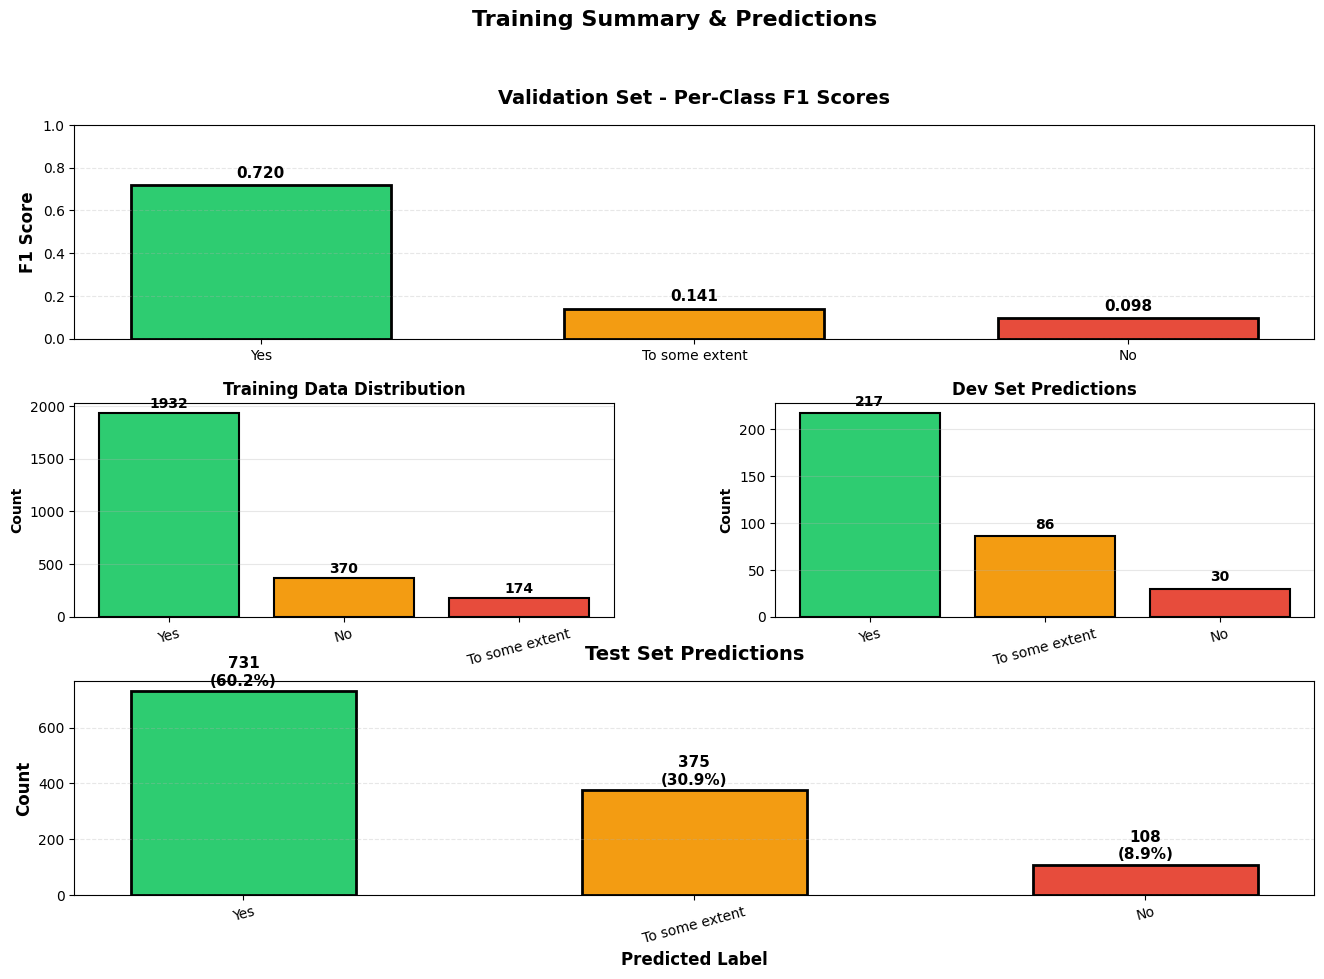

✓ Training summary visualization saved to: training_summary.png


In [16]:
# Create training summary
print(f"\n{'='*80}")
print("TRAINING SUMMARY")
print(f"{'='*80}")
print(f"Model: {MODEL_NAME}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"\nValidation Set Performance:")
print(f"  Accuracy: {val_results['eval_accuracy']:.4f}")
print(f"  F1 (Macro): {val_results['eval_f1_macro']:.4f}")
print(f"  F1 (Weighted): {val_results['eval_f1_weighted']:.4f}")

print(f"\nPer-Class F1 Scores:")
print(f"  Yes: {val_results['eval_f1_yes']:.4f}")
print(f"  To some extent: {val_results['eval_f1_to_some_extent']:.4f}")
print(f"  No: {val_results['eval_f1_no']:.4f}")

print(f"\n{'='*80}")
print("PREDICTIONS GENERATED")
print(f"{'='*80}")
print(f"✓ Dev set: {len(dev_results_df)} predictions → dev_predictions.csv")
print(f"✓ Test set: {len(test_results_df)} predictions → test_predictions.csv")
print(f"{'='*80}\n")

# Create visualization comparing training performance and prediction distributions
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Validation Set - Per-Class F1
ax1 = fig.add_subplot(gs[0, :])
class_names = ['Yes', 'To some extent', 'No']
val_f1_scores = [val_results['eval_f1_yes'], val_results['eval_f1_to_some_extent'], val_results['eval_f1_no']]
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax1.bar(class_names, val_f1_scores, color=colors, edgecolor='black', linewidth=2, width=0.6)
ax1.set_ylabel('F1 Score', fontweight='bold', fontsize=12)
ax1.set_title('Validation Set - Per-Class F1 Scores', fontweight='bold', fontsize=14, pad=15)
ax1.set_ylim([0, 1.0])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar, score in zip(bars, val_f1_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

# 2. Training Data Distribution
ax2 = fig.add_subplot(gs[1, 0])
train_counts = train_df['label'].value_counts()
bars = ax2.bar(train_counts.index, train_counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax2.set_title('Training Data Distribution', fontweight='bold', fontsize=12)
ax2.set_ylabel('Count', fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, train_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, count + 20, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 3. Dev Set Predictions
ax3 = fig.add_subplot(gs[1, 1])
dev_pred_counts = pd.Series([id2label[label] for label in dev_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in dev_pred_counts.index]
bars = ax3.bar(dev_pred_counts.index, dev_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=1.5)
ax3.set_title('Dev Set Predictions', fontweight='bold', fontsize=12)
ax3.set_ylabel('Count', fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, dev_pred_counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, count + 5, str(count), 
            ha='center', va='bottom', fontweight='bold')

# 4. Test Set Predictions
ax4 = fig.add_subplot(gs[2, :])
test_pred_counts = pd.Series([id2label[label] for label in test_pred_labels]).value_counts()
colors_pred = ['#2ecc71' if label == 'Yes' else '#f39c12' if label == 'To some extent' else '#e74c3c' 
               for label in test_pred_counts.index]
bars = ax4.bar(test_pred_counts.index, test_pred_counts.values, color=colors_pred, edgecolor='black', linewidth=2, width=0.5)
ax4.set_title('Test Set Predictions', fontweight='bold', fontsize=14, pad=15)
ax4.set_ylabel('Count', fontweight='bold', fontsize=12)
ax4.set_xlabel('Predicted Label', fontweight='bold', fontsize=12)
ax4.tick_params(axis='x', rotation=15)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for bar, count in zip(bars, test_pred_counts.values):
    ax4.text(bar.get_x() + bar.get_width()/2, count + 10, 
            f'{count}\n({count/len(test_pred_labels)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.suptitle('Training Summary & Predictions', fontsize=16, fontweight='bold', y=0.995)
plt.savefig('training_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training summary visualization saved to: training_summary.png")

## 14. Final Summary

In [17]:
print(f"\n{'='*80}")
print("🎉 TRAINING & PREDICTION COMPLETE!")
print(f"{'='*80}")
print(f"\n✅ Model trained successfully on {len(train_dataset)} samples")
print(f"✅ Validation F1-Macro: {val_results['eval_f1_macro']:.4f}")
print(f"✅ Predictions generated for {len(dev_results_df)} dev samples")
print(f"✅ Predictions generated for {len(test_results_df)} test samples")

print(f"\n📁 Output Files:")
print(f"  - best_model/mistake-identification/ → Trained model & tokenizer")
print(f"  - dev_predictions.csv → Dev set predictions with probabilities")
print(f"  - test_predictions.csv → Test set predictions with probabilities")
print(f"  - confusion_matrix_validation.png → Validation confusion matrix")
print(f"  - prediction_distributions.png → Pred distributions for dev/test")
print(f"  - training_summary.png → Complete training summary")
print(f"  - label_distribution.png → Training data distribution")

print(f"\n📊 Next Steps:")
print(f"  1. Review predictions in CSV files")
print(f"  2. Analyze model confidence scores (probabilities)")
print(f"  3. Use model for inference on new conversations")
print(f"  4. Fine-tune if needed based on domain feedback")

print(f"\n{'='*80}\n")


🎉 TRAINING & PREDICTION COMPLETE!

✅ Model trained successfully on 1980 samples
✅ Validation F1-Macro: 0.3198
✅ Predictions generated for 333 dev samples
✅ Predictions generated for 1214 test samples

📁 Output Files:
  - best_model/mistake-identification/ → Trained model & tokenizer
  - dev_predictions.csv → Dev set predictions with probabilities
  - test_predictions.csv → Test set predictions with probabilities
  - confusion_matrix_validation.png → Validation confusion matrix
  - prediction_distributions.png → Pred distributions for dev/test
  - training_summary.png → Complete training summary
  - label_distribution.png → Training data distribution

📊 Next Steps:
  1. Review predictions in CSV files
  2. Analyze model confidence scores (probabilities)
  3. Use model for inference on new conversations
  4. Fine-tune if needed based on domain feedback




## 🎉 Complete!

### Summary
- **Model**: DeBERTa-v3-base (Microsoft)
- **Task**: 3-class mistake identification
- **Training**: 2,400 samples with 80/20 train/val split
- **Inference**: Dev (328 samples) + Test (1,200 samples)

### Key Features
✓ State-of-the-art DeBERTa for nuanced understanding  
✓ Weighted loss to handle class imbalance  
✓ Early stopping to prevent overfitting  
✓ Comprehensive validation metrics  
✓ Predictions with confidence scores  

### Output Files
- `best_model/mistake-identification/` - Trained model & tokenizer
- `dev_predictions.csv` - Dev set predictions with probabilities
- `test_predictions.csv` - Test set predictions with probabilities
- `confusion_matrix_validation.png` - Validation confusion matrix
- `prediction_distributions.png` - Distribution visualizations
- `training_summary.png` - Complete training summary
- `label_distribution.png` - Training data distribution

### Using Predictions
The CSV files contain:
- `conversation_history` - Original conversation
- `tutor_response` - Tutor's response
- `predicted_label` - Model's prediction (Yes/To some extent/No)
- `prob_yes`, `prob_to_some_extent`, `prob_no` - Confidence scores

### Next Steps
1. Review predictions and confidence scores
2. Use the model for real-time inference
3. Fine-tune on additional labeled data if available
4. Deploy for production use